# Chess Winner Prediction
End-to-end ML pipeline: EDA → Feature Engineering → Model Training → Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
OUTPUT_DIR = os.path.dirname(os.path.abspath("__file__"))

## 1. Load Data

In [2]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "games.csv"))
print(f"Shape: {df.shape}")
print(df.dtypes)
df.head(3)

Shape: (20058, 16)
id                    str
rated                bool
created_at        float64
last_move_at      float64
turns               int64
victory_status        str
winner                str
increment_code        str
white_id              str
white_rating        int64
black_id              str
black_rating        int64
moves                 str
opening_eco           str
opening_name          str
opening_ply         int64
dtype: object


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3


## 2. Exploratory Data Analysis

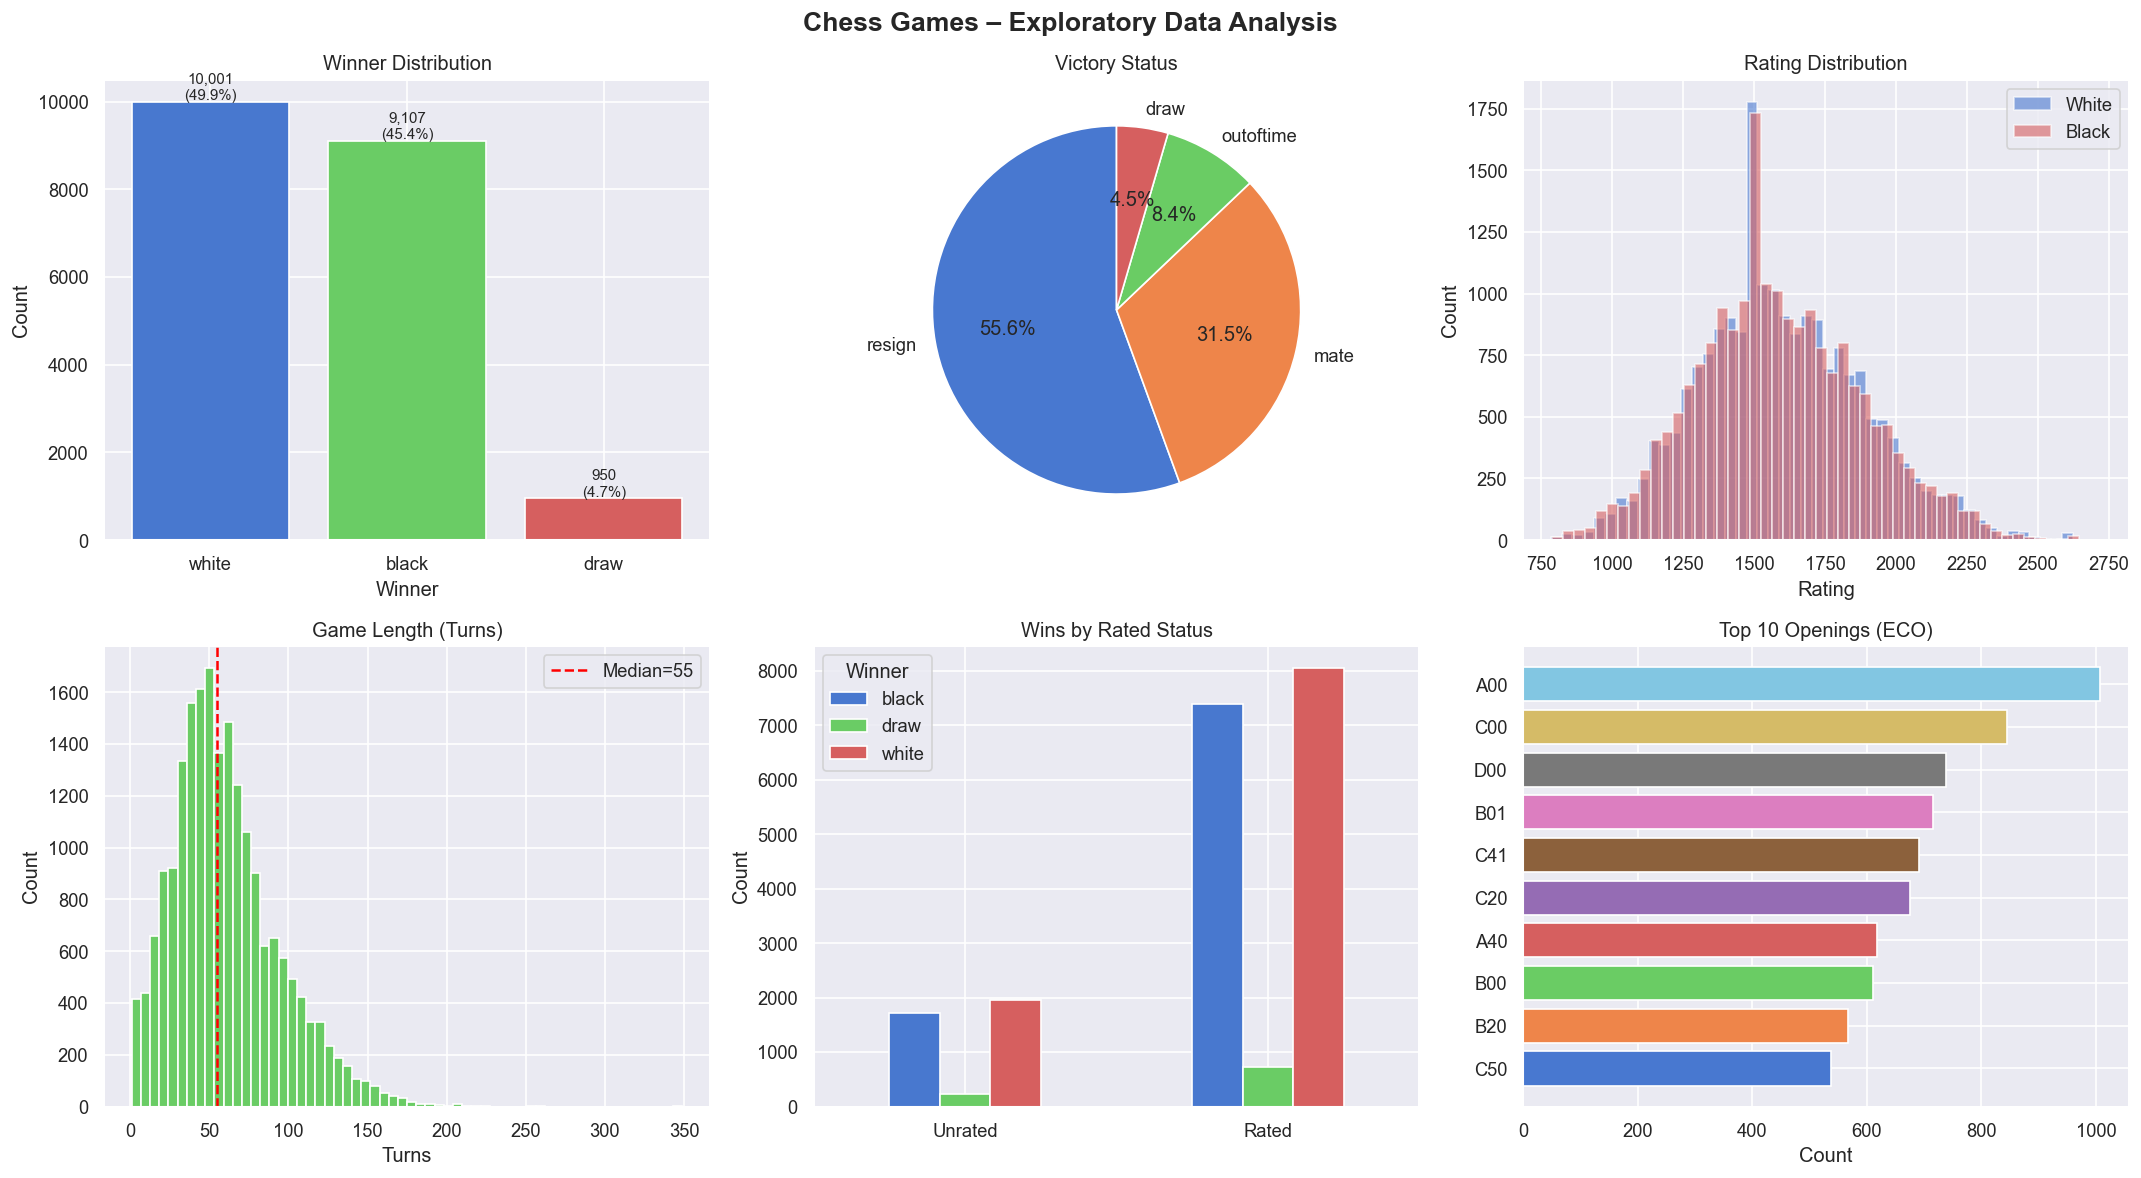

Saved eda_plots.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Chess Games – Exploratory Data Analysis", fontsize=16, fontweight="bold")

# Winner distribution
ax = axes[0, 0]
vc = df["winner"].value_counts()
colors = ["#4878CF", "#6ACC65", "#D65F5F"]
ax.bar(vc.index, vc.values, color=colors)
ax.set_title("Winner Distribution")
ax.set_xlabel("Winner"); ax.set_ylabel("Count")
for i, (k, v) in enumerate(vc.items()):
    ax.text(i, v + 50, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

# Victory status
ax = axes[0, 1]
vs = df["victory_status"].value_counts()
ax.pie(vs.values, labels=vs.index, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("muted", len(vs)))
ax.set_title("Victory Status")

# Rating distribution
ax = axes[0, 2]
ax.hist(df["white_rating"], bins=50, alpha=0.6, label="White", color="#4878CF")
ax.hist(df["black_rating"], bins=50, alpha=0.6, label="Black", color="#D65F5F")
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
ax.legend()

# Turns distribution
ax = axes[1, 0]
ax.hist(df["turns"], bins=60, color="#6ACC65", edgecolor="white")
ax.set_title("Game Length (Turns)")
ax.set_xlabel("Turns"); ax.set_ylabel("Count")
ax.axvline(df["turns"].median(), color="red", linestyle="--",
           label=f'Median={df["turns"].median():.0f}')
ax.legend()

# Rated vs Unrated wins
ax = axes[1, 1]
rated_win = df.groupby(["rated", "winner"]).size().unstack(fill_value=0)
rated_win.index = ["Unrated", "Rated"]
rated_win.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("Wins by Rated Status")
ax.set_xlabel(""); ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Winner")

# Top 10 openings
ax = axes[1, 2]
top_openings = df["opening_eco"].value_counts().head(10)
ax.barh(top_openings.index[::-1], top_openings.values[::-1],
        color=sns.color_palette("muted", 10))
ax.set_title("Top 10 Openings (ECO)")
ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_plots.png"), bbox_inches="tight")
plt.show()
print("Saved eda_plots.png")

## 3. Feature Engineering

In [4]:
data = df.copy()
data["rated"] = data["rated"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})
data["rating_diff"] = data["white_rating"] - data["black_rating"]
data["avg_rating"]  = (data["white_rating"] + data["black_rating"]) / 2

le_eco = LabelEncoder()
data["opening_eco_enc"] = le_eco.fit_transform(data["opening_eco"].fillna("UNK"))

FEATURES = [
    "rated", "turns", "white_rating", "black_rating",
    "rating_diff", "avg_rating", "opening_eco_enc", "opening_ply"
]
TARGET = "winner"

X = data[FEATURES]
y = data[TARGET]

print(f"Feature matrix: {X.shape}")
print(f"Target classes: {y.unique()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Feature matrix: (20058, 8)
Target classes: <StringArray>
['white', 'black', 'draw']
Length: 3, dtype: str
Train: (16046, 8)  Test: (4012, 8)


## 4. Train Models

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    print(f"Training {name} …")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv  = cross_val_score(model, X, y, cv=5, scoring="accuracy", n_jobs=-1).mean()
    results[name] = {"model": model, "y_pred": y_pred, "accuracy": acc, "cv_accuracy": cv}
    print(f"  Test accuracy : {acc:.4f}")
    print(f"  CV accuracy   : {cv:.4f}")
    print(classification_report(y_test, y_pred, digits=4))
    print()

Training Logistic Regression …
  Test accuracy : 0.6241
  CV accuracy   : 0.6233
              precision    recall  f1-score   support

       black     0.6141    0.5895    0.6015      1822
        draw     0.3333    0.0053    0.0104       190
       white     0.6323    0.7145    0.6709      2000

    accuracy                         0.6241      4012
   macro avg     0.5266    0.4364    0.4276      4012
weighted avg     0.6099    0.6241    0.6081      4012


Training Random Forest …
  Test accuracy : 0.6488
  CV accuracy   : 0.6478
              precision    recall  f1-score   support

       black     0.6355    0.6372    0.6363      1822
        draw     0.6000    0.1105    0.1867       190
       white     0.6609    0.7105    0.6848      2000

    accuracy                         0.6488      4012
   macro avg     0.6321    0.4861    0.5026      4012
weighted avg     0.6465    0.6488    0.6392      4012


Training Gradient Boosting …
  Test accuracy : 0.8081
  CV accuracy   : 0.7954
 

## 5. Results Visualisations

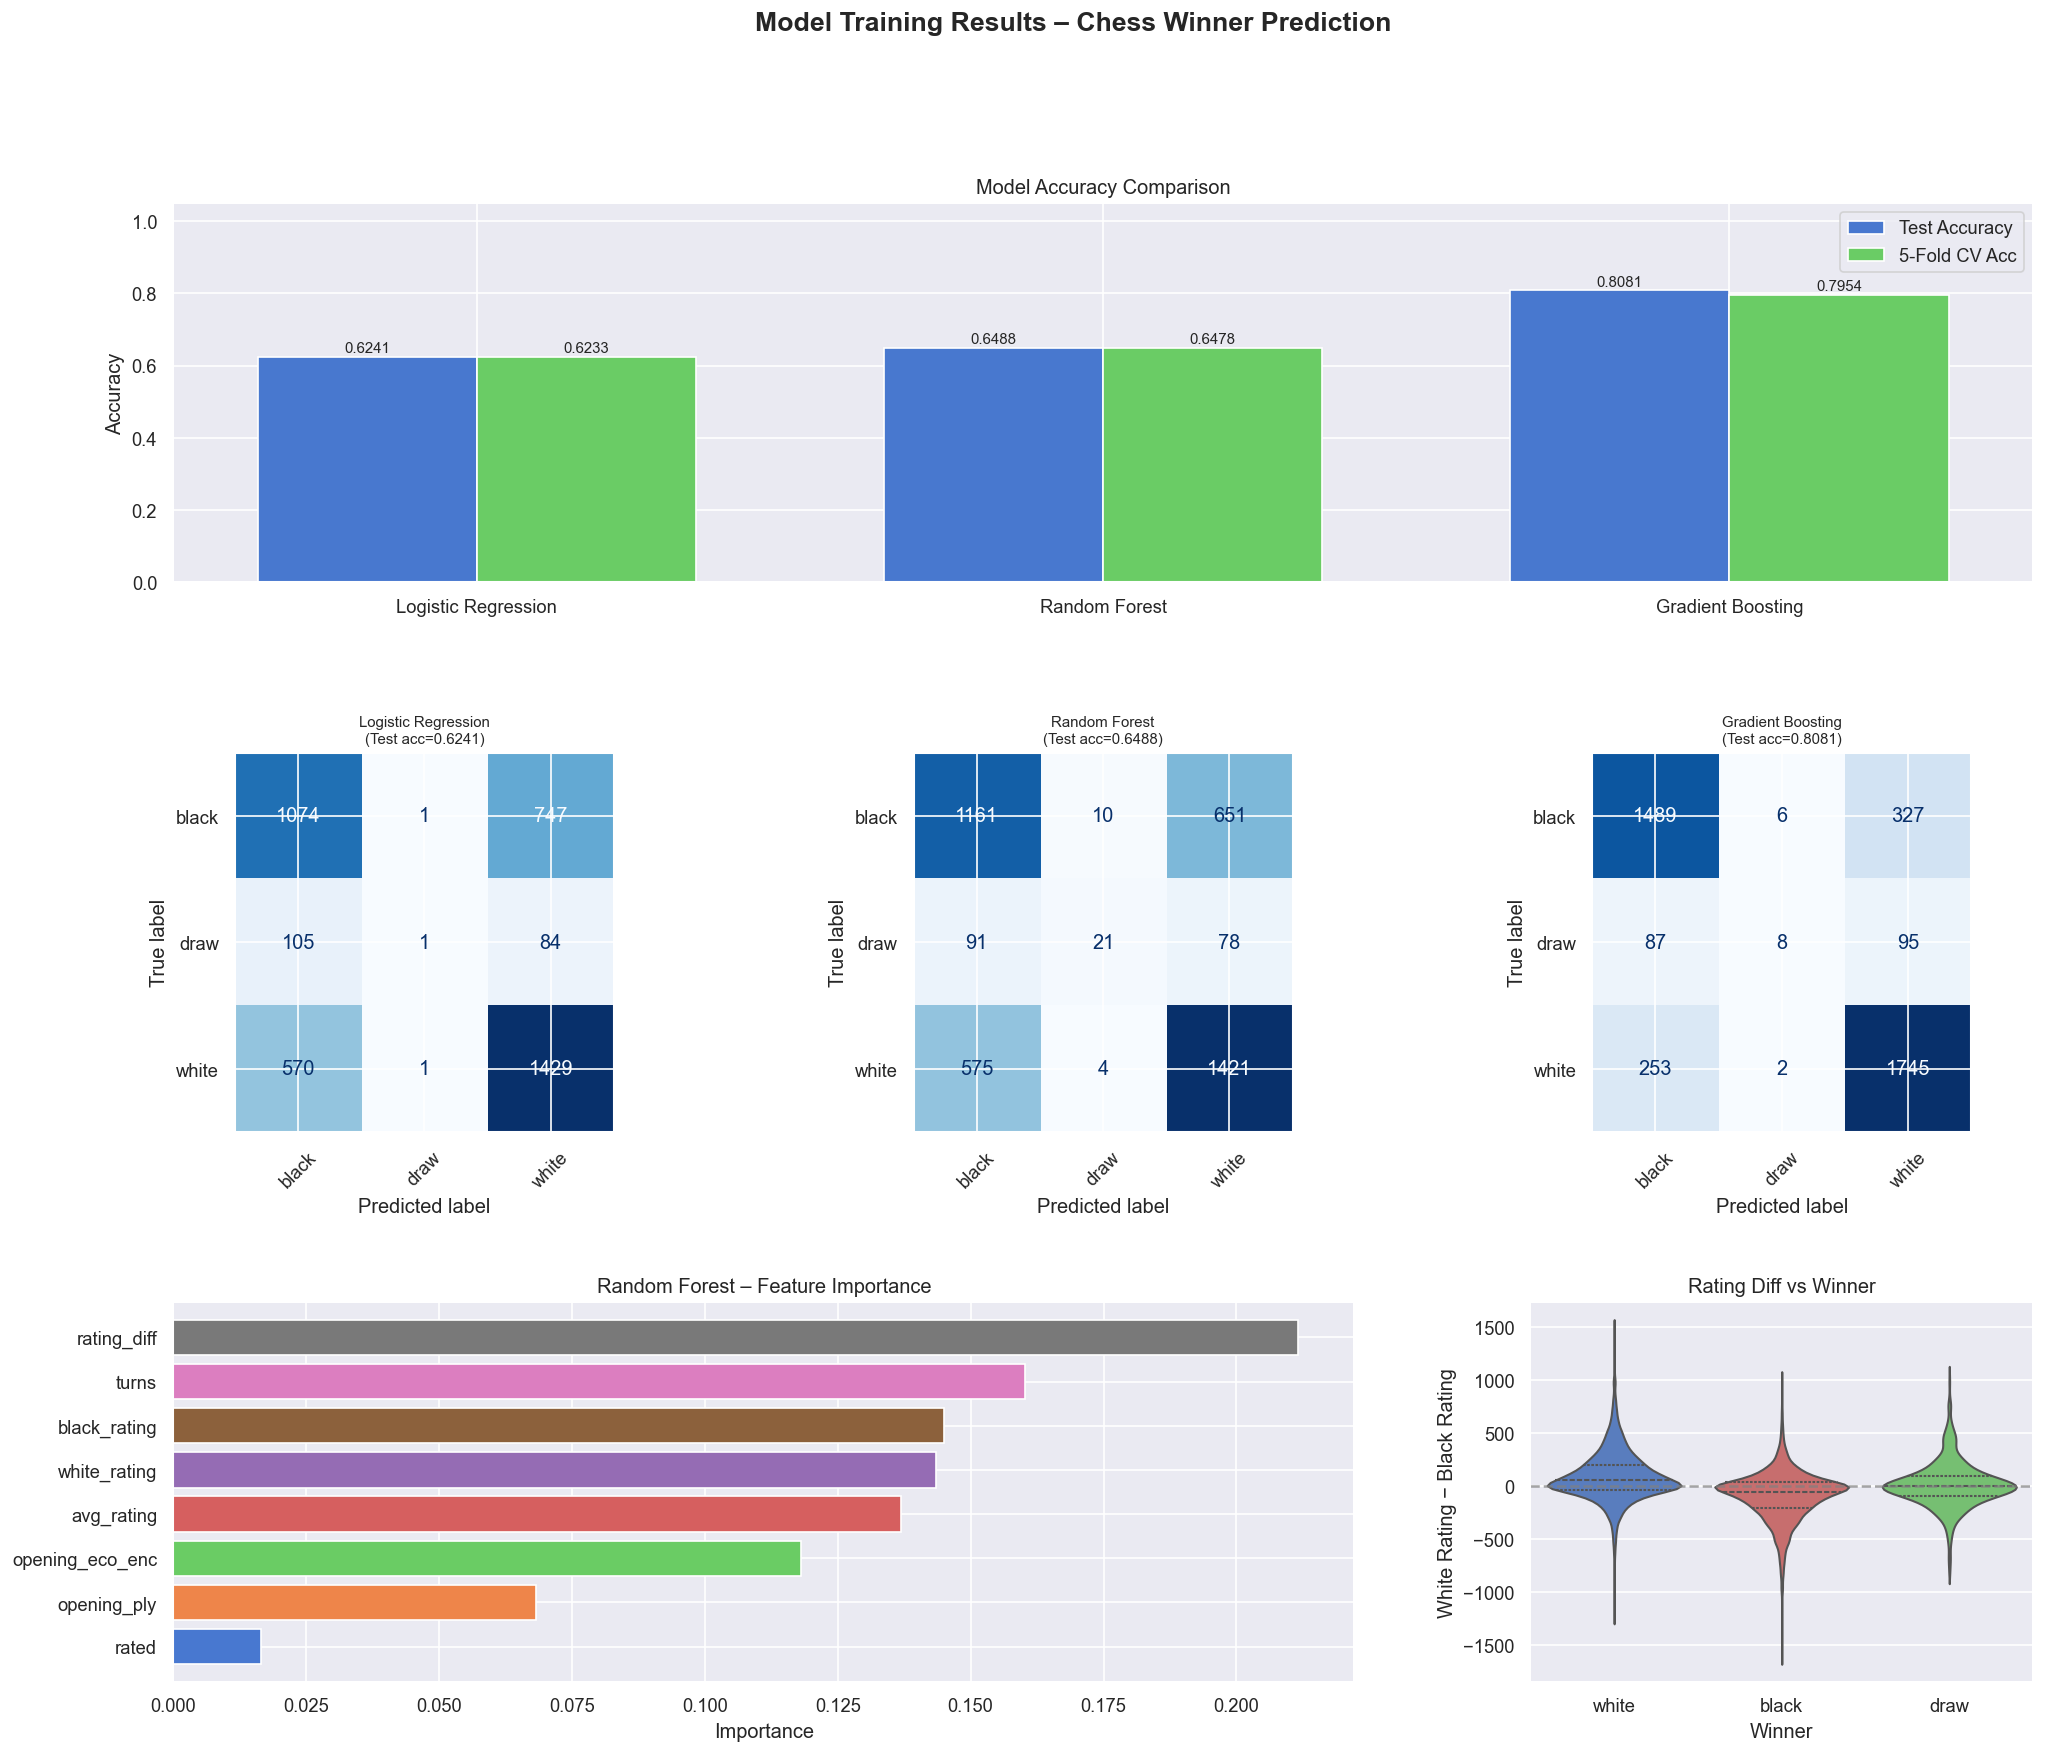

Saved model_results.png


In [6]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Model Training Results – Chess Winner Prediction", fontsize=16, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Model comparison bar chart
ax_cmp = fig.add_subplot(gs[0, :])
names     = list(results.keys())
test_accs = [results[n]["accuracy"]    for n in names]
cv_accs   = [results[n]["cv_accuracy"] for n in names]
x = np.arange(len(names))
width = 0.35
bars1 = ax_cmp.bar(x - width/2, test_accs, width, label="Test Accuracy",  color="#4878CF")
bars2 = ax_cmp.bar(x + width/2, cv_accs,   width, label="5-Fold CV Acc",  color="#6ACC65")
ax_cmp.set_xticks(x); ax_cmp.set_xticklabels(names, fontsize=11)
ax_cmp.set_ylim(0, 1.05)
ax_cmp.set_ylabel("Accuracy")
ax_cmp.set_title("Model Accuracy Comparison")
ax_cmp.legend()
for bar in bars1:
    ax_cmp.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax_cmp.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

# Confusion matrices
classes = sorted(y.unique())
for i, (name, res) in enumerate(results.items()):
    ax_cm = fig.add_subplot(gs[1, i])
    cm = confusion_matrix(y_test, res["y_pred"], labels=classes)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
    ax_cm.set_title(f"{name}\n(Test acc={res['accuracy']:.4f})", fontsize=9)
    ax_cm.tick_params(axis="x", rotation=45)

# Feature importance (Random Forest)
ax_fi = fig.add_subplot(gs[2, :2])
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
ax_fi.barh(importances.index, importances.values, color=sns.color_palette("muted", len(importances)))
ax_fi.set_title("Random Forest – Feature Importance")
ax_fi.set_xlabel("Importance")

# Rating diff vs winner (violin)
ax_vio = fig.add_subplot(gs[2, 2])
order_present = [o for o in ["white", "black", "draw"] if o in df["winner"].unique()]
sns.violinplot(data=data, x="winner", y="rating_diff", order=order_present,
               palette={"white": "#4878CF", "black": "#D65F5F", "draw": "#6ACC65"},
               ax=ax_vio, inner="quartile")
ax_vio.set_title("Rating Diff vs Winner")
ax_vio.set_xlabel("Winner"); ax_vio.set_ylabel("White Rating − Black Rating")
ax_vio.axhline(0, color="gray", linestyle="--", alpha=0.7)

plt.savefig(os.path.join(OUTPUT_DIR, "model_results.png"), bbox_inches="tight")
plt.show()
print("Saved model_results.png")

## 6. Best Model Summary

In [7]:
best_name = max(results, key=lambda n: results[n]["accuracy"])
best_acc  = results[best_name]["accuracy"]
print(f"{'='*50}")
print(f"Best model : {best_name}")
print(f"Test acc   : {best_acc:.4f}")
print(f"{'='*50}")
print("\nPlots saved to:", OUTPUT_DIR)

Best model : Gradient Boosting
Test acc   : 0.8081

Plots saved to: d:\ANIMESH\ML projects\Chess
